 (LYDIA TOLULOPE OMOSOFE SUKD2301999)

TASK1: Data Loading and Exploration


In [ ]:
# Install Java
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  openjdk-11-jre-headless
Suggested packages:
  openjdk-11-demo openjdk-11-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-11-jdk-headless openjdk-11-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 118 not upgraded.
Need to get 116 MB of archives.
After this operation, 258 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 openjdk-11-jre-headless amd64 11.0.30+7-1ubuntu1~22.04 [42.6 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd6

In [ ]:
# Download Spark
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz

In [ ]:
# Install findspark (helps Python locate Spark)
!pip install -q findspark

In [ ]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import mean, stddev, col
from pyspark.sql.types import IntegerType, DoubleType, FloatType

# Start Spark session
spark = (SparkSession.builder
         .master("local[*]")
         .appName("Assignment")
         .getOrCreate())

print("Spark started successfully")


Spark started successfully


In [ ]:
# Upload OnlineRetail.csv from computer
from google.colab import files
uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail.csv


In [ ]:
# Load CSV file into a Spark DataFrame
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)

print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
# Show a quick summary of the dataset
# Gives count, mean, stddev, min, max for numeric columns
df.describe().show()

+-------+------------------+------------------+--------------------+-----------------+----------------+-----------------+------------------+-----------+
|summary|         InvoiceNo|         StockCode|         Description|         Quantity|     InvoiceDate|        UnitPrice|        CustomerID|    Country|
+-------+------------------+------------------+--------------------+-----------------+----------------+-----------------+------------------+-----------+
|  count|            541909|            541909|              540455|           541909|          541909|           541909|            406829|     541909|
|   mean|  559965.752026781|27623.240210938104|             20713.0| 9.55224954743324|            NULL|4.611113626082965|15287.690570239585|       NULL|
| stddev|13428.417280799484| 16799.73762842768|                NULL|218.0811578502348|            NULL|96.75985306117944|1713.6003033215932|       NULL|
|    min|            536365|             10002| 4 PURPLE FLOCK D...|           -80

In [ ]:
# Check for missing/null values in each column
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()


+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [ ]:
# See which countries appear the most
# Helps understand distribution of records
df.groupBy("Country") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(10)


+--------------+------+
|       Country| count|
+--------------+------+
|United Kingdom|495478|
|       Germany|  9495|
|        France|  8557|
|          EIRE|  8196|
|         Spain|  2533|
|   Netherlands|  2371|
|       Belgium|  2069|
|   Switzerland|  2002|
|      Portugal|  1519|
|     Australia|  1259|
+--------------+------+
only showing top 10 rows


In [ ]:
# Show structure: column names + data types
df.printSchema()


root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
# Display first 10 records
df.show(10)


+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01-12-2010 08:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01-12-2010 08:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01-12-2010 08:26|     3.39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|01-12-2010 08:26|     7.65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|01-1

In [ ]:
# Show last 10 records
df.orderBy(df.columns[0], ascending=False).show(10)


+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|  C581569|    84978|HANGING HEART JAR...|      -1|09-12-2011 11:58|     1.25|     17315|United Kingdom|
|  C581569|    20979|36 PENCILS TUBE R...|      -5|09-12-2011 11:58|     1.25|     17315|United Kingdom|
|  C581568|    21258|VICTORIAN SEWING ...|      -5|09-12-2011 11:57|    10.95|     15311|United Kingdom|
|  C581499|        M|              Manual|      -1|09-12-2011 10:28|   224.69|     15498|United Kingdom|
|  C581490|    22178|VICTORIAN GLASS H...|     -12|09-12-2011 09:57|     1.95|     14397|United Kingdom|
|  C581490|    23144|ZINC T-LIGHT HOLD...|     -11|09-12-2011 09:57|     0.83|     14397|United Kingdom|
|  C581484|    23843|PAPER CRAFT , LIT...|  -80995|09-1

In [ ]:
# Print all column names
print("Columns in dataset:")
print(df.columns)


Columns in dataset:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [ ]:
# Count total number of rows
print("Total records:", df.count())


Total records: 541909


In [ ]:
# Import proper type classes
from pyspark.sql.types import IntegerType, DoubleType, FloatType
from pyspark.sql.functions import mean, stddev, expr

# Detect numeric columns properly
numeric_columns = [
    field.name for field in df.schema.fields
    if isinstance(field.dataType, (IntegerType, DoubleType, FloatType))
]

print("Numeric columns:", numeric_columns)


Numeric columns: ['Quantity', 'UnitPrice', 'CustomerID']


In [ ]:
# Mean and Standard Deviation
df.select(
    [mean(c).alias(f"mean_{c}") for c in numeric_columns] +
    [stddev(c).alias(f"stddev_{c}") for c in numeric_columns]
).show()


+----------------+-----------------+------------------+-----------------+-----------------+------------------+
|   mean_Quantity|   mean_UnitPrice|   mean_CustomerID|  stddev_Quantity| stddev_UnitPrice| stddev_CustomerID|
+----------------+-----------------+------------------+-----------------+-----------------+------------------+
|9.55224954743324|4.611113626082965|15287.690570239585|218.0811578502348|96.75985306117944|1713.6003033215932|
+----------------+-----------------+------------------+-----------------+-----------------+------------------+



In [ ]:
# Median
df.select(
    [expr(f'percentile({c}, 0.5)').alias(f"median_{c}") for c in numeric_columns]
).show()


+---------------+----------------+-----------------+
|median_Quantity|median_UnitPrice|median_CustomerID|
+---------------+----------------+-----------------+
|            3.0|            2.08|          15152.0|
+---------------+----------------+-----------------+



TASK 2

*Part 1:Data Cleaning and Preprocessing*

In [ ]:
# Identify missing or null values
# Count null values in each column
from pyspark.sql.functions import col, sum

null_counts = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

null_counts.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [ ]:
# Remove rows where CustomerID is null
df_clean = df.dropna(subset=["CustomerID"])

print("Remaining records after removing null CustomerID:", df_clean.count())

Remaining records after removing null CustomerID: 406829


In [ ]:
# Data transformations
from pyspark.sql.functions import to_timestamp

df_clean = df.withColumn(
    "InvoiceDate",
    to_timestamp("InvoiceDate", "dd-MM-yyyy HH:mm")
)

In [ ]:
# Check schema again
df_clean.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
# Filter data based on specific conditions
# Now we remove rows that break analysis logic
from pyspark.sql.functions import col

df_filtered = df_clean.filter(
    (col("CustomerID").isNotNull()) &
    (col("InvoiceDate").isNotNull()) &
    (col("Quantity") > 0) &
    (col("UnitPrice") > 0)
)

print("Records after cleaning:", df_filtered.count())

Records after cleaning: 397884


In [ ]:
#Create newly derived columns
from pyspark.sql.functions import round

df_final = df_filtered.withColumn(
    "TotalAmount",
    round(col("Quantity") * col("UnitPrice"), 2)
)

df_final.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|TotalAmount|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|United Kingdom|       15.3|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|      20.34|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|United Kingdom|       22.0|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|      20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|     17850|United Kingdom|      20.34|
+---------+---------+-------------------

*Part 2: Data Analysis and Aggregation*


In [ ]:
# Group-by aggregations

#Top 10 countries by total sales

df_final.groupBy("Country") \
    .sum("TotalAmount") \
    .withColumnRenamed("sum(TotalAmount)", "TotalSales") \
    .orderBy("TotalSales", ascending=False) \
    .show(10)

+--------------+------------------+
|       Country|        TotalSales|
+--------------+------------------+
|United Kingdom| 7308391.550000211|
|   Netherlands| 285446.3399999992|
|          EIRE|265545.89999999915|
|       Germany|228867.14000000025|
|        France|209024.05000000022|
|     Australia|138521.30999999976|
|         Spain| 61577.11000000017|
|   Switzerland|56443.950000000084|
|       Belgium| 41196.34000000001|
|        Sweden| 38378.32999999999|
+--------------+------------------+
only showing top 10 rows


In [ ]:
# Top 10 customers by total spending

df_final.groupBy("CustomerID") \
    .sum("TotalAmount") \
    .withColumnRenamed("sum(TotalAmount)", "TotalSpent") \
    .orderBy("TotalSpent", ascending=False) \
    .show(10)

+----------+------------------+
|CustomerID|        TotalSpent|
+----------+------------------+
|     14646| 280206.0199999994|
|     18102|259657.29999999996|
|     17450|194550.78999999995|
|     16446|          168472.5|
|     14911|143825.05999999988|
|     12415| 124914.5299999998|
|     14156|117379.62999999992|
|     17511| 91062.37999999989|
|     16029| 81024.84000000001|
|     12346|           77183.6|
+----------+------------------+
only showing top 10 rows


In [ ]:
# Window Functions(for ranking)
#Rank customers by spending
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

window_spec = Window.orderBy(col("TotalSpent").desc())

customer_sales = df_final.groupBy("CustomerID") \
    .sum("TotalAmount") \
    .withColumnRenamed("sum(TotalAmount)", "TotalSpent")

customer_ranked = customer_sales.withColumn(
    "Rank",
    rank().over(window_spec)
)

customer_ranked.show(10)


+----------+------------------+----+
|CustomerID|        TotalSpent|Rank|
+----------+------------------+----+
|     14646| 280206.0199999994|   1|
|     18102|259657.29999999996|   2|
|     17450|194550.78999999995|   3|
|     16446|          168472.5|   4|
|     14911|143825.05999999988|   5|
|     12415| 124914.5299999998|   6|
|     14156|117379.62999999992|   7|
|     17511| 91062.37999999989|   8|
|     16029| 81024.84000000001|   9|
|     12346|           77183.6|  10|
+----------+------------------+----+
only showing top 10 rows


In [ ]:
#Cumulative sum (window function example)
from pyspark.sql.functions import sum as spark_sum

window_spec2 = Window.orderBy("InvoiceDate") \
                     .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_cumulative = df_final.withColumn(
    "CumulativeSales",
    spark_sum("TotalAmount").over(window_spec2)
)

df_cumulative.select("InvoiceDate", "TotalAmount", "CumulativeSales").show(10)

+-------------------+-----------+------------------+
|        InvoiceDate|TotalAmount|   CumulativeSales|
+-------------------+-----------+------------------+
|2010-12-01 08:26:00|       15.3|              15.3|
|2010-12-01 08:26:00|      20.34|             35.64|
|2010-12-01 08:26:00|       22.0|             57.64|
|2010-12-01 08:26:00|      20.34|             77.98|
|2010-12-01 08:26:00|      20.34| 98.32000000000001|
|2010-12-01 08:26:00|       15.3|            113.62|
|2010-12-01 08:26:00|       25.5|            139.12|
|2010-12-01 08:28:00|       11.1|            150.22|
|2010-12-01 08:28:00|       11.1|            161.32|
|2010-12-01 08:34:00|      54.08|215.39999999999998|
+-------------------+-----------+------------------+
only showing top 10 rows


In [ ]:
#Join operation
# for example total sales per country and join it back

country_sales = df_final.groupBy("Country") \
    .sum("TotalAmount") \
    .withColumnRenamed("sum(TotalAmount)", "CountryTotal")

df_joined = df_final.join(
    country_sales,
    on="Country",
    how="left"
)

df_joined.show(5)

+--------------+---------+---------+--------------------+--------+-------------------+---------+----------+-----------+-----------------+
|       Country|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|TotalAmount|     CountryTotal|
+--------------+---------+---------+--------------------+--------+-------------------+---------+----------+-----------+-----------------+
|United Kingdom|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|     17850|       15.3|7308391.550000211|
|United Kingdom|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|     17850|      20.34|7308391.550000211|
|United Kingdom|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|     17850|       22.0|7308391.550000211|
|United Kingdom|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|     17850|      20.34|7308391.550000211|
|United Kingdom|   536365|   84029

TASK 3: ADVANCED ANALYSIS


Objective: To
predict a customer's total spending using Linear Regression, then tune it with hyperparameter search, and visualise the results.

In [ ]:
# first we reproduce cleaned DataFrame (Tasks 1 & 2 pipeline)
from pyspark.sql.functions import col, to_timestamp, round as spark_round

raw = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)

df_final = (
    raw
    .withColumn("InvoiceDate", to_timestamp("InvoiceDate", "dd-MM-yyyy HH:mm"))
    .filter(
        col("CustomerID").isNotNull()  &
        col("InvoiceDate").isNotNull() &
        (col("Quantity")  > 0)         &
        (col("UnitPrice") > 0)
    )
    .withColumn("TotalAmount", spark_round(col("Quantity") * col("UnitPrice"), 2))
)

print("Clean records:", df_final.count())
df_final.printSchema()


Clean records: 397884
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- TotalAmount: double (nullable = true)



STEP2:  Feature Engineering: Build the ML Feature Set


In [ ]:

#We aggregate to one row per customer with three predictive features:TotalOrders, TotalQuantity, AvgUnitPrice, TotalSpent
# Aggregate per customer

from pyspark.sql.functions import countDistinct, sum as spark_sum, avg

customer_features = (
    df_final
    .groupBy("CustomerID")
    .agg(
        countDistinct("InvoiceNo").alias("TotalOrders"),
        spark_sum("Quantity").alias("TotalQuantity"),
        avg("UnitPrice").alias("AvgUnitPrice"),
        spark_sum("TotalAmount").alias("TotalSpent")
    )
)

print("Customer feature rows:", customer_features.count())
customer_features.show(10)


Customer feature rows: 4338
+----------+-----------+-------------+------------------+------------------+
|CustomerID|TotalOrders|TotalQuantity|      AvgUnitPrice|        TotalSpent|
+----------+-----------+-------------+------------------+------------------+
|     17389|         34|         7612| 5.688826291079812|31833.679999999997|
|     14450|          3|          241|2.7904999999999998|            483.25|
|     15727|          7|         3065|3.2481456953642383|           5178.96|
|     13285|          4|         2051| 2.134866310160428|2709.1199999999994|
|     14570|          2|           95|3.3720689655172422|218.05999999999995|
|     16503|          4|          569| 4.173571428571429|1431.9299999999998|
|     17420|          3|          265| 3.881333333333332| 598.8299999999999|
|     15447|          1|           85|3.1211111111111114|            155.17|
|     13623|          5|          294| 3.594444444444445| 747.7800000000001|
|     18024|          2|          184|2.58285714

STEP3: Prepare MLlib Pipeline (VectorAssembler + LinearRegression)

In [ ]:
#Assemble feature vector
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

feature_cols = ["TotalOrders", "TotalQuantity", "AvgUnitPrice"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

lr = LinearRegression(
    featuresCol="features",
    labelCol="TotalSpent",
    predictionCol="prediction"
)

pipeline = Pipeline(stages=[assembler, scaler, lr])
print("Pipeline created successfully.")


Pipeline created successfully.


STEP 4: Train/Test Split and Baseline Model Training


In [ ]:
#  80/20 split
train_df, test_df = customer_features.randomSplit([0.8, 0.2], seed=42)

print(f"Training samples : {train_df.count()}")
print(f"Test samples     : {test_df.count()}")


Training samples : 3517
Test samples     : 821


In [ ]:
# Train baseline model
baseline_model = pipeline.fit(train_df)
predictions     = baseline_model.transform(test_df)

predictions.select("CustomerID", "TotalSpent", "prediction").show(10)

+----------+------------------+-------------------+
|CustomerID|        TotalSpent|         prediction|
+----------+------------------+-------------------+
|     12348|           1797.24|  3885.768859556717|
|     12353|              89.0|-28.989165482254066|
|     12355|             459.4|  314.8298711703719|
|     12360|2662.0599999999995| 1922.4508444144951|
|     12367|             168.9| 201.99950076735058|
|     12373|             364.6|  247.6937574370852|
|     12380|           2724.81| 1922.9086431918531|
|     12390| 549.8399999999999|  495.3198484083953|
|     12403|             427.7|  98.30754389257277|
|     12405|1710.3900000000006| 1302.7654034447062|
+----------+------------------+-------------------+
only showing top 10 rows


STEP5: Baseline Model Evaluation

In [ ]:
# Evaluate Baseline
# Metrics Used:
# RMSE– Root Mean Squared Error (lower is better)
# MAE – Mean Absolute Error (lower is better)
# R² – Coefficient of Determination (closer to 1 is better)



from pyspark.ml.evaluation import RegressionEvaluator

def evaluate(predictions, label="TotalSpent"):
    metrics = {}
    for metric in ["rmse", "mae", "r2"]:
        evaluator = RegressionEvaluator(
            labelCol=label,
            predictionCol="prediction",
            metricName=metric
        )
        metrics[metric] = evaluator.evaluate(predictions)
    return metrics

baseline_metrics = evaluate(predictions)

print("=== Baseline Model Performance ===")
print(f"  RMSE : {baseline_metrics['rmse']:,.2f}")
print(f"  MAE  : {baseline_metrics['mae']:,.2f}")
print(f"  R²   : {baseline_metrics['r2']:.4f}")


=== Baseline Model Performance ===
  RMSE : 2,216.61
  MAE  : 537.41
  R²   : 0.8738


STEP6: Hyperparameter Tuning With CrossValidator

In [ ]:
# Hyperparameter grid
# 5fold cross-validation is used

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr_stage = pipeline.getStages()[-1]   # LinearRegression stage

param_grid = (
    ParamGridBuilder()
    .addGrid(lr_stage.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr_stage.elasticNetParam, [0.0, 0.5, 1.0])
    .addGrid(lr_stage.maxIter,         [50, 100])
    .build()
)

cv_evaluator = RegressionEvaluator(
    labelCol="TotalSpent",
    predictionCol="prediction",
    metricName="rmse"
)

cross_validator = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=5,
    seed=42
)

print(f"Grid size: {len(param_grid)} hyperparameter combinations × 5 folds = {len(param_grid)*5} fits")


Grid size: 18 hyperparameter combinations × 5 folds = 90 fits


In [ ]:
# Run cross-validation
cv_model      = cross_validator.fit(train_df)
best_model    = cv_model.bestModel
best_preds    = best_model.transform(test_df)

print("Cross-validation complete.")


Cross-validation complete.


In [ ]:

# Extract best hyperparameters from the fitted LR stage
best_lr = best_model.stages[-1]
print(f"\nBest hyperparameters found:")
print(f"  regParam        : {best_lr.getRegParam()}")
print(f"  elasticNetParam : {best_lr.getElasticNetParam()}")
print(f"  maxIter         : {best_lr.getMaxIter()}")


Best hyperparameters found:
  regParam        : 0.5
  elasticNetParam : 1.0
  maxIter         : 50


STEP7: Tuned Model Evaluation & Comparison

In [ ]:
# Compare baseline vs tuned
tuned_metrics = evaluate(best_preds)

print("╔══════════════════════════════════════════╗")
print("║      Model Performance Comparison        ║")
print("╠══════════════╦══════════════╦════════════╣")
print("║ Metric       ║   Baseline   ║   Tuned    ║")
print("╠══════════════╬══════════════╬════════════╣")
print(f"║ RMSE         ║ {baseline_metrics['rmse']:>12,.2f} ║ {tuned_metrics['rmse']:>10,.2f} ║")
print(f"║ MAE          ║ {baseline_metrics['mae']:>12,.2f} ║ {tuned_metrics['mae']:>10,.2f} ║")
print(f"║ R²           ║ {baseline_metrics['r2']:>12.4f} ║ {tuned_metrics['r2']:>10.4f} ║")
print("╚══════════════╩══════════════╩════════════╝")

rmse_improvement = ((baseline_metrics['rmse'] - tuned_metrics['rmse']) / baseline_metrics['rmse']) * 100
print(f"\nRMSE improvement after tuning: {rmse_improvement:.2f}%")

╔══════════════════════════════════════════╗
║      Model Performance Comparison        ║
╠══════════════╦══════════════╦════════════╣
║ Metric       ║   Baseline   ║   Tuned    ║
╠══════════════╬══════════════╬════════════╣
║ RMSE         ║     2,216.61 ║   2,216.52 ║
║ MAE          ║       537.41 ║     537.34 ║
║ R²           ║       0.8738 ║     0.8738 ║
╚══════════════╩══════════════╩════════════╝

RMSE improvement after tuning: 0.00%


In [ ]:
#  Model coefficients and intercept
import pandas as pd

coefficients = best_lr.coefficients.toArray()
coeff_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": coefficients
})
print("Best Model — Coefficients:")
print(coeff_df.to_string(index=False))
print(f"\nIntercept: {best_lr.intercept:.4f}")

Best Model — Coefficients:
      Feature  Coefficient
  TotalOrders   505.333384
TotalQuantity  8489.888146
 AvgUnitPrice   189.774263

Intercept: 2097.3832


STEP8: Visualisation


In [ ]:
#We export the predictions to Pandas and use Matplotlib / Seaborn for four key plots:
#1. Actual vs Predicted Spending
#2. Residuals Distribution
#3. Feature Coefficients (importance)
#4. RMSE Comparison — Baseline vs Tuned

# Export predictions to Pandas
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

pred_pd = best_preds.select("CustomerID", "TotalSpent", "prediction").toPandas()
pred_pd["Residual"] = pred_pd["TotalSpent"] - pred_pd["prediction"]

print("Sample predictions:")
print(pred_pd.head(10).to_string(index=False))


Sample predictions:
 CustomerID  TotalSpent  prediction     Residual
      12348     1797.24 3885.694887 -2088.454887
      12353       89.00  -28.806592   117.806592
      12355      459.40  315.024724   144.375276
      12360     2662.06 1922.518549   739.541451
      12367      168.90  202.212167   -33.312167
      12373      364.60  247.886038   116.713962
      12380     2724.81 1922.941000   801.869000
      12390      549.84  495.510681    54.329319
      12403      427.70   98.471743   329.228257
      12405     1710.39 1302.931858   407.458142


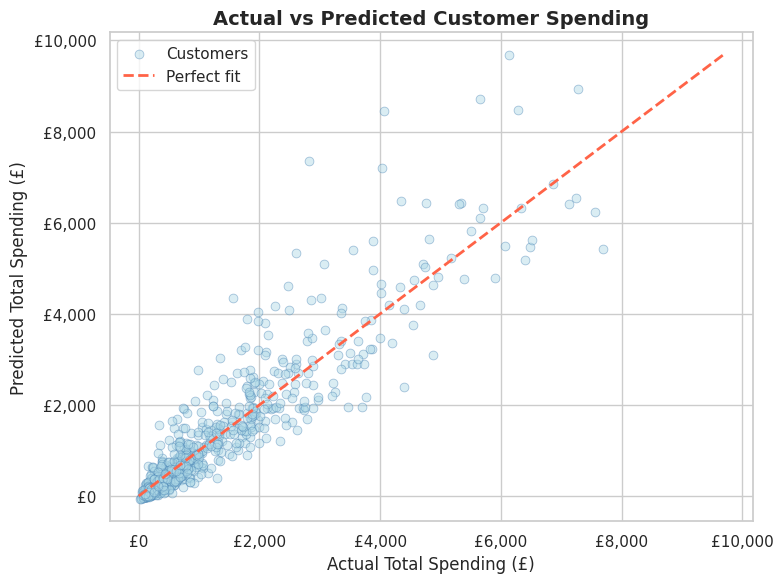

Plot 1 saved.


In [ ]:
#  Plot 1: Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))

# Cap extreme outliers for a cleaner plot
cap = pred_pd["TotalSpent"].quantile(0.97)
plot_df = pred_pd[pred_pd["TotalSpent"] <= cap].copy()

ax.scatter(plot_df["TotalSpent"], plot_df["prediction"],
           alpha=0.45, edgecolors="steelblue", facecolors="lightblue",
           s=40, linewidths=0.6, label="Customers")

lim = max(plot_df["TotalSpent"].max(), plot_df["prediction"].max())
ax.plot([0, lim], [0, lim], color="tomato", lw=2, linestyle="--", label="Perfect fit")

ax.set_xlabel("Actual Total Spending (£)", fontsize=12)
ax.set_ylabel("Predicted Total Spending (£)", fontsize=12)
ax.set_title("Actual vs Predicted Customer Spending", fontsize=14, fontweight="bold")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig("plot1_actual_vs_predicted.png", dpi=150)
plt.show()
print("Plot 1 saved.")

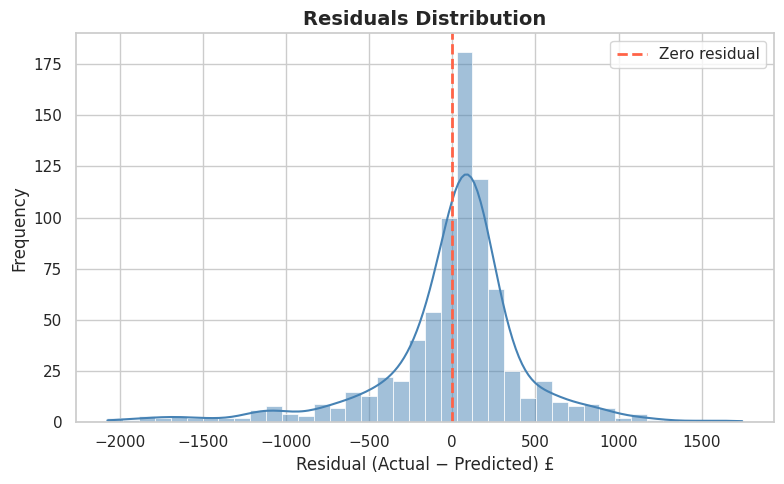

Plot 2 saved.


In [ ]:
# Plot 2: Residuals Distribution
fig, ax = plt.subplots(figsize=(8, 5))

res_cap = pred_pd["Residual"].quantile(0.98)
res_lo  = pred_pd["Residual"].quantile(0.02)
res_trimmed = pred_pd[(pred_pd["Residual"] >= res_lo) & (pred_pd["Residual"] <= res_cap)]["Residual"]

sns.histplot(res_trimmed, bins=40, kde=True, color="steelblue",
             edgecolor="white", linewidth=0.5, ax=ax)
ax.axvline(0, color="tomato", linestyle="--", lw=2, label="Zero residual")

ax.set_xlabel("Residual (Actual − Predicted) £", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Residuals Distribution", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plot2_residuals.png", dpi=150)
plt.show()
print("Plot 2 saved.")


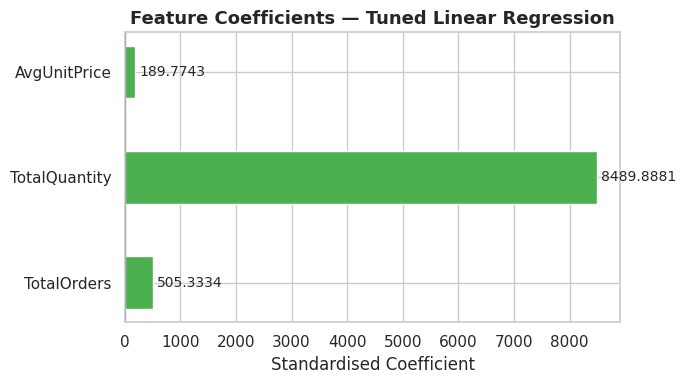

Plot 3 saved.


In [ ]:
# Plot 3: Feature Coefficients
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#4CAF50" if c > 0 else "#F44336" for c in coeff_df["Coefficient"]]
bars = ax.barh(coeff_df["Feature"], coeff_df["Coefficient"],
               color=colors, edgecolor="white", height=0.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_xlabel("Standardised Coefficient", fontsize=12)
ax.set_title("Feature Coefficients — Tuned Linear Regression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_coefficients.png", dpi=150)
plt.show()
print("Plot 3 saved.")

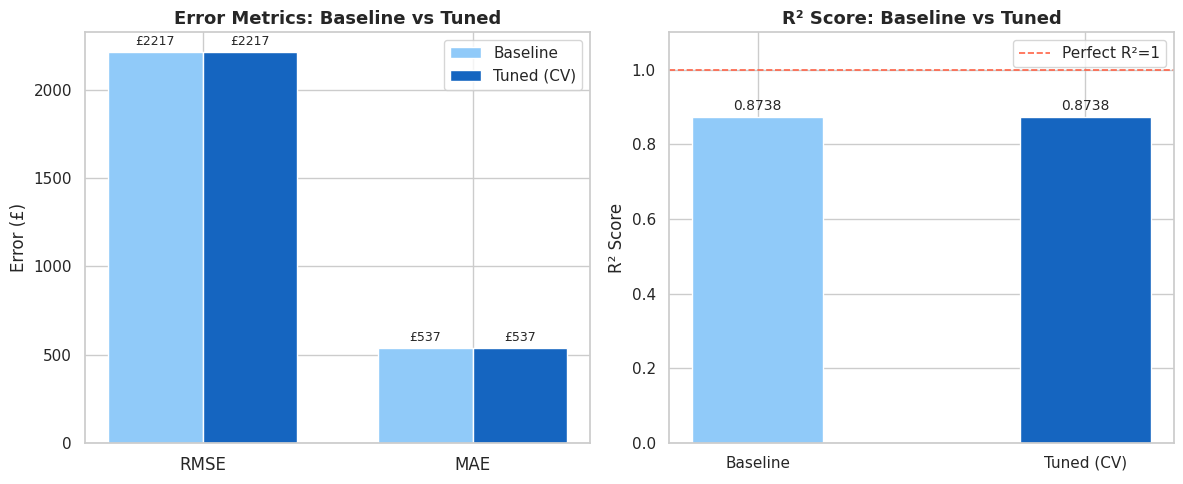

Plot 4 saved.


In [ ]:
 # Plot 4: RMSE/MAE/R² Baseline vs Tuned
metrics_labels = ["RMSE", "MAE"]
baseline_vals  = [baseline_metrics["rmse"],  baseline_metrics["mae"]]
tuned_vals     = [tuned_metrics["rmse"],     tuned_metrics["mae"]]

x = np.arange(len(metrics_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: RMSE & MAE bar chart
ax1 = axes[0]
rects1 = ax1.bar(x - width/2, baseline_vals, width, label="Baseline",
                 color="#90CAF9", edgecolor="white")
rects2 = ax1.bar(x + width/2, tuned_vals,    width, label="Tuned (CV)",
                 color="#1565C0", edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_labels, fontsize=12)
ax1.set_ylabel("Error (£)", fontsize=12)
ax1.set_title("Error Metrics: Baseline vs Tuned", fontsize=13, fontweight="bold")
ax1.bar_label(rects1, fmt="£%.0f", padding=3, fontsize=9)
ax1.bar_label(rects2, fmt="£%.0f", padding=3, fontsize=9)
ax1.legend()

# Right: R² bar chart
ax2 = axes[1]
r2_vals = [baseline_metrics["r2"], tuned_metrics["r2"]]
bar_colors = ["#90CAF9", "#1565C0"]
b = ax2.bar(["Baseline", "Tuned (CV)"], r2_vals, color=bar_colors,
            edgecolor="white", width=0.4)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("R² Score", fontsize=12)
ax2.set_title("R² Score: Baseline vs Tuned", fontsize=13, fontweight="bold")
ax2.bar_label(b, fmt="%.4f", padding=3, fontsize=10)
ax2.axhline(1.0, color="tomato", linestyle="--", lw=1.2, label="Perfect R²=1")
ax2.legend()

plt.tight_layout()
plt.savefig("plot4_metrics_comparison.png", dpi=150)
plt.show()
print("Plot 4 saved.")